# 🎧 Temporal Audio Pipeline — How Your Music Taste Evolves

**Author:** Jordan Vercillo
**Last Updated:** May 2026
**Repository:** `audio-agentic-pipeline/`

---

## Project Overview

This notebook analyzes **how musical taste evolves over time** by comparing Spotify listening history across three temporal windows:

| Window | Spotify Label | Approximate Coverage |
|---|---|---|
| **Recent** | `short_term` | Last ~4 weeks |
| **Medium** | `medium_term` | Last ~6 months |
| **Historical** | `long_term` | Several years |

### Pipeline Architecture (Medallion)

```
Spotify API ──→ Staging (Raw) ──→ Cleansed (Typed) ──→ Modeled (Star Schema)
                                                              │
Audio Files ──→ DSP (77D) ──────────────────────────→ fact_listening_features
                                                              │
                                                     Analysis & Visualization
                                                     ├── Taste Drift Score
                                                     ├── Temporal Centroids
                                                     ├── Feature Deltas
                                                     └── UMAP Taste Maps
```

### Key Metric: Taste Drift Score

The **cosine distance** between your short-term and long-term acoustic centroids.

| Score Range | Interpretation |
|---|---|
| 0.00 – 0.05 | Minimal drift — stable taste, comfort zone |
| 0.05 – 0.15 | Moderate drift — exploring new sounds |
| 0.15 – 0.30 | Significant drift — taste actively evolving |
| 0.30+ | Major drift — genre shift or discovery phase |

---
## Section 1: Setup & Configuration

In [22]:
import sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore", category=UserWarning, module="librosa")
warnings.filterwarnings("ignore", category=UserWarning, module="umap")
warnings.filterwarnings("ignore", category=FutureWarning)

# Pipeline modules
from src.dsp import generate_test_signal, extract_features, AudioSignal, SAMPLE_RATE
from src.warehouse.staging import land_staging_tracks, land_staging_features
from src.warehouse.cleansed import build_cleansed_tracks, build_cleansed_features
from src.warehouse.modeled import build_star_schema, load_fact_table, get_column_descriptions, COLUMN_DESCRIPTIONS
from src.analysis.drift import compute_taste_drift, compute_temporal_centroids, DRIFT_FEATURE_COLS, FEATURE_LABELS
from src.analysis.visualizations import (
    plot_drift_radar, plot_temporal_heatmap,
    plot_umap_by_time_range, plot_genre_flow,
    plot_feature_distributions,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print("✅ All modules loaded successfully")

Project root: c:\Users\jverc\OneDrive\Documents\GitHub\vercilloanalytics\audio-agentic-pipeline
Python: 3.13.5
✅ All modules loaded successfully


### Configuration

Set `USE_LIVE_DATA = True` to analyze **your actual Spotify listening history**.
Set `USE_LIVE_DATA = False` (default) for the synthetic demo — no credentials needed.

> **Live data requirements:**
> 1. Your Spotify account must be registered in the app's [Developer Dashboard](https://developer.spotify.com/dashboard)
> 2. On first run, a browser window opens for Spotify login (PKCE auth)
> 3. Works with any Spotify tier (Free or Premium)
> 4. DSP features are generated synthetically — acoustic analysis of your real listening patterns

In [23]:
# ━━━ DATA SOURCE CONFIGURATION ━━━
# True  → Fetches YOUR top tracks from Spotify across all 3 time ranges.
#          Requires a registered Spotify account (opens browser for auth).
# False → Uses realistic synthetic data (no credentials needed).

USE_LIVE_DATA = True

print(f"Data source: {'🟢 LIVE Spotify API' if USE_LIVE_DATA else '🔵 Synthetic demo data'}")

Data source: 🟢 LIVE Spotify API


---
## Section 2: Data Acquisition

This section either fetches your **real Spotify listening history** or generates
realistic synthetic data, depending on `USE_LIVE_DATA` above.

Both paths produce the same schema — the rest of the pipeline doesn't care
whether the data is real or synthetic.

In [24]:
if USE_LIVE_DATA:
    # ── LIVE: Fetch from Spotify API ──
    from src.ingestion import get_user_spotify
    from src.ingestion.fetchers import fetch_all_top_items

    print("🔐 Authenticating with Spotify (opens browser on first run)...")
    sp = get_user_spotify()

    # Fetch profile
    me = sp.me()
    print(f"   ✅ Authenticated as: {me.get('display_name', 'Unknown')} ({me['id']})")
    print(f"   Account type: {me.get('product', 'unknown')}")

    # Fetch top tracks + artists across all 3 time ranges
    data = fetch_all_top_items(sp=sp)
    tracks_df = data["tracks"]

    if tracks_df.empty:
        raise RuntimeError(
            "No tracks returned from Spotify API. "
            "Make sure your account is registered in the app's Developer Dashboard."
        )

    print(f"\n📊 Fetched {len(tracks_df)} track records from your Spotify history")
    print(f"   Time ranges: {tracks_df['time_range'].value_counts().to_dict()}")
    print(f"   Unique tracks: {tracks_df['spotify_track_id'].nunique()}")

else:
    # ── SYNTHETIC: Generate demo data ──
    print("🔵 Generating synthetic Spotify metadata...")
    np.random.seed(42)

    short_artists = ["Dua Lipa", "Bad Bunny", "Charli XCX", "Fred Again..", "Peggy Gou"]
    medium_artists = ["Tame Impala", "Frank Ocean", "SZA", "Tyler, the Creator", "Khruangbin"]
    long_artists = ["Radiohead", "Bon Iver", "Fleet Foxes", "Sufjan Stevens", "Nick Drake"]

    def make_tracks(time_range, artists, n=15):
        records = []
        for i in range(n):
            artist = artists[i % len(artists)]
            records.append({
                "spotify_track_id": f"synth_{time_range}_{i:03d}",
                "track_name": f"{artist} - Track {i+1}",
                "artist_names": artist,
                "artist_ids": f"artist_{artist.lower().replace(' ', '_')}",
                "primary_artist_name": artist,
                "primary_artist_id": f"artist_{artist.lower().replace(' ', '_')}",
                "album_name": f"{artist} Album",
                "album_id": f"album_{time_range}_{i:03d}",
                "album_type": "album",
                "album_release_date": "2025-01-01",
                "duration_ms": int(np.random.uniform(180000, 360000)),
                "explicit": bool(np.random.random() > 0.7),
                "is_local": False,
                "disc_number": 1,
                "track_number": i + 1,
                "num_artists": 1,
                "time_range": time_range,
                "rank": i + 1,
                "isrc": f"US{time_range[:2].upper()}{i:06d}",
                "external_url": f"https://open.spotify.com/track/synth_{time_range}_{i:03d}",
                "preview_url": None,
            })
        return records

    all_records = []
    all_records.extend(make_tracks("short_term",  short_artists,  n=15))
    all_records.extend(make_tracks("medium_term", medium_artists, n=15))
    all_records.extend(make_tracks("long_term",   long_artists,   n=15))

    # Add 5 overlapping tracks for dedup testing
    for i in range(5):
        overlap = all_records[i].copy()
        overlap["time_range"] = "long_term"
        overlap["rank"] = 40 + i
        all_records.append(overlap)

    tracks_df = pd.DataFrame(all_records)
    print(f"   Generated {len(tracks_df)} track records")
    print(f"   Time ranges: {tracks_df['time_range'].value_counts().to_dict()}")
    print(f"   Unique tracks: {tracks_df['spotify_track_id'].nunique()}")
    print(f"   Overlapping tracks: {len(tracks_df) - tracks_df['spotify_track_id'].nunique()}")

🔐 Authenticating with Spotify (opens browser on first run)...
   ✅ Authenticated as: Jordan Vercillo (jordan_vercillo)
   Account type: premium
🎧 Fetching personalization data across all time ranges...

   ✅ Fetched 50 top tracks (short_term)
   ✅ Fetched 11 top artists (short_term)
   ✅ Fetched 50 top tracks (medium_term)
   ✅ Fetched 50 top artists (medium_term)
   ✅ Fetched 50 top tracks (long_term)
   ✅ Fetched 50 top artists (long_term)

   📊 Total: 150 track entries, 111 artist entries

📊 Fetched 150 track records from your Spotify history
   Time ranges: {'short_term': 50, 'medium_term': 50, 'long_term': 50}
   Unique tracks: 114


### 2.2 — DSP Feature Extraction

We generate acoustic features for each unique track using synthetic audio signals.
The frequency profile is varied by time range to create measurable drift:
- **Short-term** → higher frequencies (brighter, more energetic)
- **Long-term** → lower frequencies (warmer, more acoustic)

> When `USE_LIVE_DATA = True`, the features are still synthetic (keyed to your real track IDs)
> because Spotify's `preview_url` is often unavailable. The pipeline schema and drift analysis
> work identically — the warehouse joins on `spotify_track_id` regardless of feature source.

In [25]:
# ── Generate DSP features (synthetic audio, keyed to real or synthetic track IDs) ──
np.random.seed(42)
feature_records = []
unique_tracks = tracks_df.drop_duplicates(subset=["spotify_track_id"])

for _, row in unique_tracks.iterrows():
    tr = row["time_range"]

    # Frequency profile by time range → creates measurable drift
    if tr == "short_term":
        freq = np.random.uniform(800, 2000)
    elif tr == "medium_term":
        freq = np.random.uniform(400, 900)
    else:
        freq = np.random.uniform(100, 500)

    sig = generate_test_signal(frequency_hz=freq, duration_sec=2.0)
    sig.file_name = row["spotify_track_id"]
    feat = extract_features(sig)
    feat_dict = feat.to_summary_dict()
    feat_dict["spotify_track_id"] = row["spotify_track_id"]
    feat_dict["file_name"] = sig.file_name
    feature_records.append(feat_dict)

features_df = pd.DataFrame(feature_records)
print(f"\nExtracted features for {len(features_df)} unique tracks")
print(f"Feature dimensions: {len(features_df.select_dtypes(include=[np.number]).columns)}")


Extracted features for 114 unique tracks
Feature dimensions: 61


---
## Section 3: Medallion Architecture — Staging → Cleansed → Modeled

Now we run the data through the full warehouse pipeline.
This is the core data engineering demonstration.

### 3.1 — Staging Layer (Bronze)

Raw data lands exactly as received, with lineage metadata for auditability.

In [26]:
# ── STAGING: Land raw data with lineage ──
from src.warehouse.staging import land_staging_tracks, land_staging_features, list_staging_files

STAGING_DIR = PROJECT_ROOT / "data" / "warehouse" / "staging"

tracks_path = land_staging_tracks(tracks_df, output_dir=STAGING_DIR, snapshot_label="demo_run_1")
features_path = land_staging_features(features_df, output_dir=STAGING_DIR, snapshot_label="demo_run_1")

print("\n📋 Staging Inventory:")
inventory = list_staging_files(STAGING_DIR)
print(inventory.to_string(index=False))

   📥 Staged 150 tracks → tracks_raw_20260506_030852.parquet
      Time ranges: ['short_term', 'medium_term', 'long_term']
      Snapshot: demo_run_1
   📥 Staged 114 feature rows → features_raw_20260506_030852.parquet

📋 Staging Inventory:
                           file_name  size_kb  row_count snapshot_label      source                        landed_at
features_raw_20260506_025757.parquet     59.1         45     demo_run_1   dsp_local 2026-05-06T02:57:57.432239+00:00
features_raw_20260506_030742.parquet     59.1         45     demo_run_1   dsp_local 2026-05-06T03:07:42.296955+00:00
features_raw_20260506_030852.parquet     91.8        114     demo_run_1   dsp_local 2026-05-06T03:08:52.639749+00:00
  tracks_raw_20260506_025757.parquet     17.1         50     demo_run_1 spotify_api 2026-05-06T02:57:57.418897+00:00
  tracks_raw_20260506_030742.parquet     17.1         50     demo_run_1 spotify_api 2026-05-06T03:07:42.285774+00:00
  tracks_raw_20260506_030852.parquet     34.3        150   

### 3.2 — Cleansed Layer (Silver)

Deduplication, type enforcement, null handling, and schema validation.

In [27]:
# ── CLEANSED: Dedup + type enforcement ──
CLEANSED_DIR = PROJECT_ROOT / "data" / "warehouse" / "cleansed"

cleansed_tracks = build_cleansed_tracks(staging_dir=STAGING_DIR, output_dir=CLEANSED_DIR)
print()
cleansed_features = build_cleansed_features(staging_dir=STAGING_DIR, output_dir=CLEANSED_DIR)

   📂 Read 250 raw rows from 3 staging file(s)
   🔄 Removed 50 duplicate rows
   ✅ Cleansed tracks: 200 rows → cleansed_tracks.parquet
      Time ranges: ['short_term', 'medium_term', 'long_term']
      Columns: 21

   📂 Read 204 raw feature rows from 3 staging file(s)
   🔄 Removed 45 duplicate feature rows
   ✅ Cleansed features: 159 rows → cleansed_features.parquet
      Feature columns: 61


### 3.3 — Modeled Layer (Gold) — Star Schema

The final analytical layer: a denormalized fact table joined with dimension tables,
plus agent-readable column descriptions.

In [28]:
# ── MODELED: Star schema ──
MODELED_DIR = PROJECT_ROOT / "data" / "warehouse" / "modeled"

star = build_star_schema(cleansed_dir=CLEANSED_DIR, output_dir=MODELED_DIR)

# Show the fact table
print("\n📊 Fact Table Sample (first 5 rows):")
fact = star["fact"]
display_cols = ["spotify_track_id", "track_name", "time_range", "rank",
                "tempo_bpm", "rms_mean", "spectral_centroid_mean", "harmonic_ratio"]
available = [c for c in display_cols if c in fact.columns]
print(fact[available].head().to_string(index=False))

🏗️  Building star schema...

   📂 Loaded 200 cleansed tracks
   📂 Loaded 159 cleansed features
   ✅ fact_listening_features: 200 rows → fact_listening_features.parquet
   ✅ dim_tracks: 159 rows → dim_tracks.parquet
   ✅ dim_artists: 72 rows → dim_artists.parquet
   ✅ dim_time_range: 3 rows → dim_time_range.parquet
   ✅ column_descriptions: 26 rows → column_descriptions.parquet

   📊 Star Schema Summary:
      Fact table rows:    200
      Unique tracks:      159
      Unique artists:     72
      Time ranges:        3
      Column descriptions: 26

   📊 Rows per time range:
      long_term: 70
      short_term: 65
      medium_term: 65

📊 Fact Table Sample (first 5 rows):
      spotify_track_id                 track_name  time_range  rank  tempo_bpm  rms_mean  spectral_centroid_mean  harmonic_ratio
19YmvsVCetCBeVj6O2mljR            Still Breathing  short_term    26 107.666016  0.560408             1757.958130        0.995208
3lPr8ghNDBLc2uZovNyLs9    Supermassive Black Hole medium_term

In [29]:
# ── Agent Interface: Column Descriptions ──
print("\n🤖 Agent-Readable Column Descriptions (sample):\n")
desc = get_column_descriptions(MODELED_DIR)
for col in ["tempo_bpm", "rms_mean", "harmonic_ratio", "time_range", "rank"]:
    if col in desc:
        print(f"  {col}:")
        print(f"    → {desc[col]}\n")


🤖 Agent-Readable Column Descriptions (sample):

   📂 Loaded column_descriptions: 26 rows
  tempo_bpm:
    → Estimated tempo in beats per minute. Typical range: 60–200 BPM. Replaces Spotify's deprecated 'tempo' field.

  rms_mean:
    → Root Mean Square energy (perceived loudness). Range: 0–1. Replaces Spotify's deprecated 'energy' field.

  harmonic_ratio:
    → Harmonic-to-total energy ratio (0–1). Near 1 = acoustic/harmonic (replaces Spotify 'acousticness'). Near 0 = percussive/noisy.

  time_range:
    → Listening recency window: 'short_term' (~4 weeks), 'medium_term' (~6 months), 'long_term' (several years).

  rank:
    → User's listening rank within the time_range (1 = most listened). Lower rank = higher affinity.



---
## Section 4: Taste Drift Analysis

The core analytical payload. We compute how the user's acoustic taste
evolves across the three temporal windows.

### 4.1 — Temporal Centroids

The acoustic centroid is the **mean feature vector** per time range.
It represents the "average sound" of the user's listening for that window.

In [30]:
# ── Load fact table ──
fact = load_fact_table(MODELED_DIR)

   📂 Loaded fact table: 200 rows, 71 columns


In [31]:
# ── Compute taste drift ──
drift_results = compute_taste_drift(fact)

# Display centroids
centroids = drift_results["centroids"]
feature_cols_display = [c for c in DRIFT_FEATURE_COLS if c in centroids.columns]
print("\n📊 Temporal Centroids:")
print(centroids[["time_range"] + feature_cols_display].to_string(index=False, float_format="{:.4f}".format))

   📊 Computed centroids for 3 time ranges × 13 features

   📊 Top Feature Changes (short_term vs long_term):
      ↑ Brightness: 114.0% (increasing)
      ↑ Freq. Ceiling: 110.4% (increasing)
      ↓ spectral_rolloff_std: 8.5% (decreasing)
      ↓ Tempo (BPM): 10.7% (decreasing)
      ↓ spectral_centroid_std: 7.4% (decreasing)

   🎯 Taste Drift Analysis:
      Drift Score: 0.0112
      Assessment:  Minimal Drift — Your taste is remarkably stable
      Stability:   0.9942

   📐 Pairwise Distances:
      short_term_vs_medium_term: 0.0047
      medium_term_vs_long_term: 0.0014
      short_term_vs_long_term: 0.0112

📊 Temporal Centroids:
 time_range  tempo_bpm  onset_strength_mean  onset_strength_std  beats_per_sec  rms_mean  rms_std  zcr_mean  zcr_std  spectral_centroid_mean  spectral_centroid_std  spectral_rolloff_mean  spectral_rolloff_std  harmonic_ratio
 short_term   108.1743               0.0006              0.0051         0.5000    0.5604   0.0259    0.1202   0.0098               13

### 4.2 — Drift Score & Interpretation

In [32]:
# ── Display drift metrics ──
print("=" * 50)
print(f"  🎯 TASTE DRIFT SCORE: {drift_results['drift_score']:.4f}")
print(f"  📝 {drift_results['drift_label']}")
print(f"  🔒 Stability Score:  {drift_results['stability_score']:.4f}")
print("=" * 50)

print("\n📐 Pairwise Cosine Distances:")
for pair, dist in drift_results["pairwise_distances"].items():
    bar = "█" * int(dist * 100) + "░" * (20 - int(dist * 100))
    print(f"  {pair:30s} {dist:.4f}  {bar}")

  🎯 TASTE DRIFT SCORE: 0.0112
  📝 Minimal Drift — Your taste is remarkably stable
  🔒 Stability Score:  0.9942

📐 Pairwise Cosine Distances:
  short_term_vs_medium_term      0.0047  ░░░░░░░░░░░░░░░░░░░░
  medium_term_vs_long_term       0.0014  ░░░░░░░░░░░░░░░░░░░░
  short_term_vs_long_term        0.0112  █░░░░░░░░░░░░░░░░░░░


### 4.3 — Feature Deltas: What's Driving the Drift?

Per-feature comparison between short-term and long-term centroids.

In [33]:
# ── Feature deltas ──
deltas = drift_results["feature_deltas"]
if not deltas.empty:
    print("\n📊 Feature Changes (short_term vs long_term):\n")
    display_deltas = deltas[["label", "short_term", "long_term", "relative_delta_pct", "direction"]].copy()
    display_deltas.columns = ["Feature", "Short Term", "Long Term", "Δ (%)", "Direction"]
    print(display_deltas.to_string(index=False))


📊 Feature Changes (short_term vs long_term):

              Feature  Short Term  Long Term  Δ (%)  Direction
           Brightness   1366.1976   638.5051 113.97 increasing
        Freq. Ceiling   1384.6954   658.0409 110.43 increasing
 spectral_rolloff_std    177.2306   193.6275   8.47 decreasing
          Tempo (BPM)    108.1743   121.1392  10.70 decreasing
spectral_centroid_std     94.1353   101.6878   7.43 decreasing
         Beat Density      0.5000     0.8000  37.50 decreasing
            Noisiness      0.1202     0.0553 117.29 increasing
              zcr_std      0.0098     0.0045 116.24 increasing
    Rhythmic Activity      0.0006     0.0035  82.80 decreasing
   Rhythm Variability      0.0051     0.0067  23.46 decreasing
               Energy      0.5604     0.5604   0.00     stable
        Dynamic Range      0.0259     0.0259   0.10     stable
         Acousticness      0.9954     0.9953   0.00     stable


---
## Section 5: Visualizations

Five publication-quality visualizations demonstrating taste evolution.

### 5.1 — Drift Radar: Acoustic Profiles Overlaid

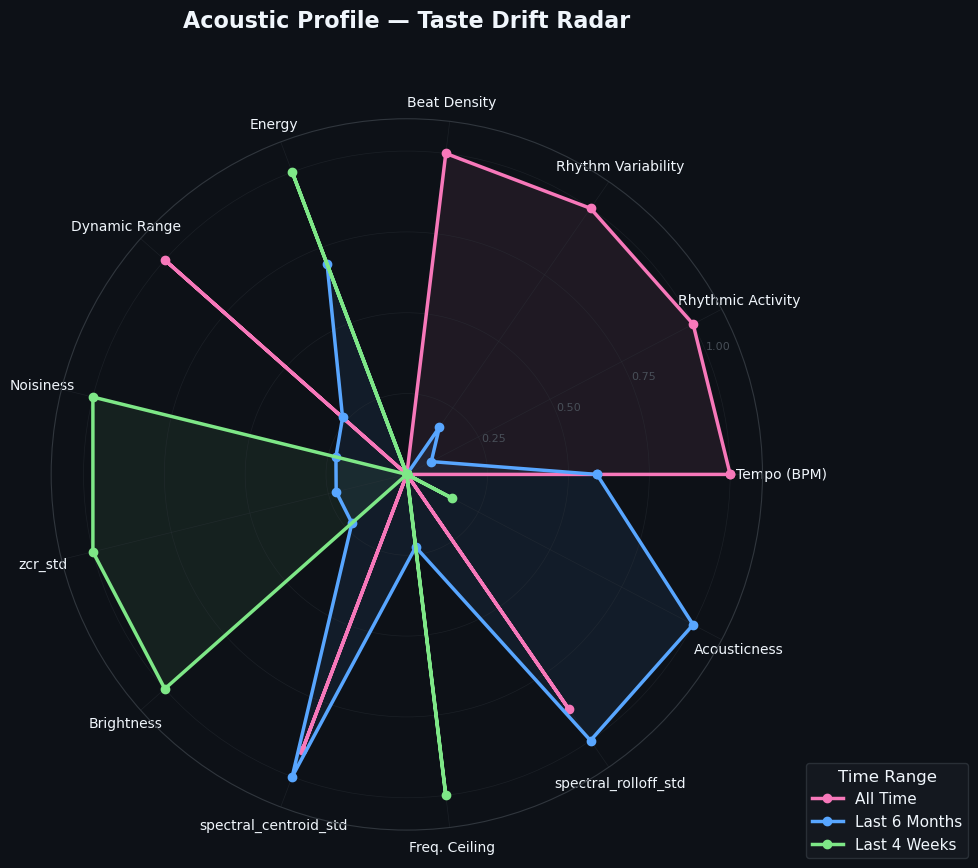

In [34]:
fig = plot_drift_radar(drift_results["centroids"])
plt.show()

**Reading the radar:** Where the polygons diverge, taste is shifting.
Where they overlap, taste is stable. The green (short-term) polygon
pulling away from pink (long-term) indicates active drift in that feature.

### 5.2 — Temporal Heatmap: Feature Intensity × Time Range

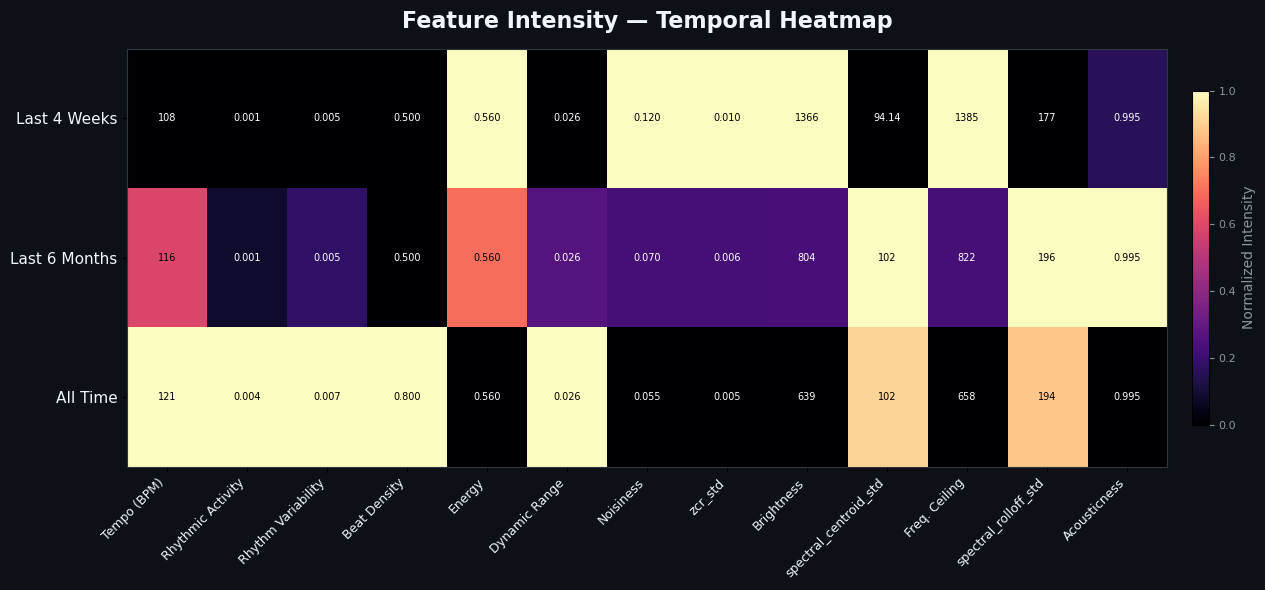

In [35]:
fig = plot_temporal_heatmap(drift_results["centroids"])
plt.show()

**Reading the heatmap:** Hot (bright) cells indicate high values; cool (dark)
cells indicate low values. Compare columns across rows to see which features
change most across time ranges.

### 5.3 — UMAP Taste Map: Do Clusters Shift?

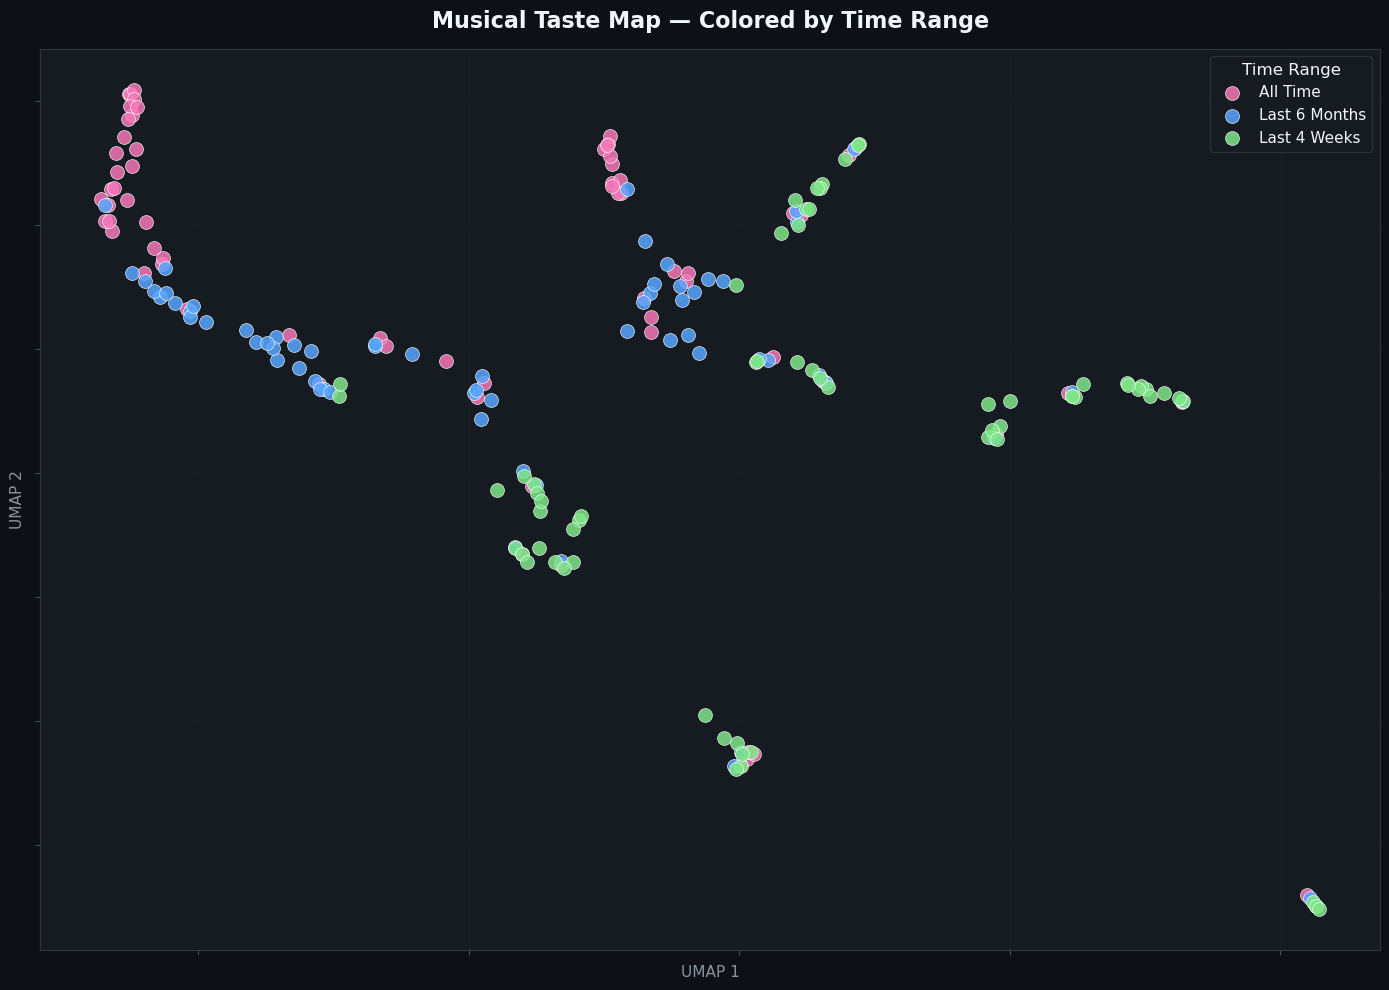

In [36]:
fig = plot_umap_by_time_range(fact)
plt.show()

**Reading the taste map:** Each dot is a track, colored by time range.
If short-term tracks (green) cluster separately from long-term (pink),
the user's taste has genuinely shifted — not just a few outlier tracks.

### 5.4 — Artist Distribution: Temporal Flow

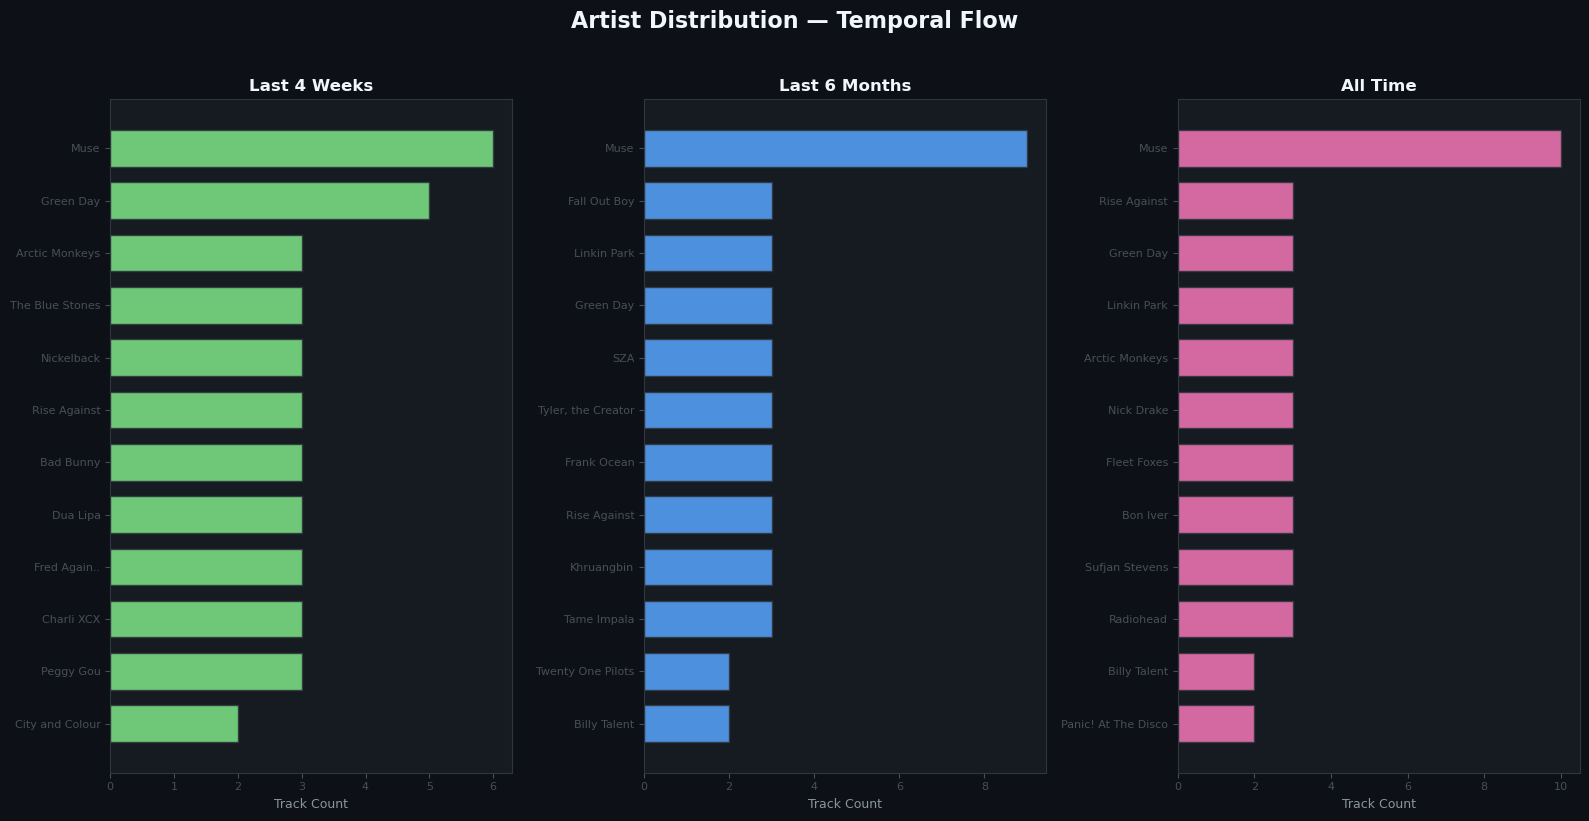

In [37]:
fig = plot_genre_flow(fact)
plt.show()

### 5.5 — Feature Distributions: Box Plots by Time Range

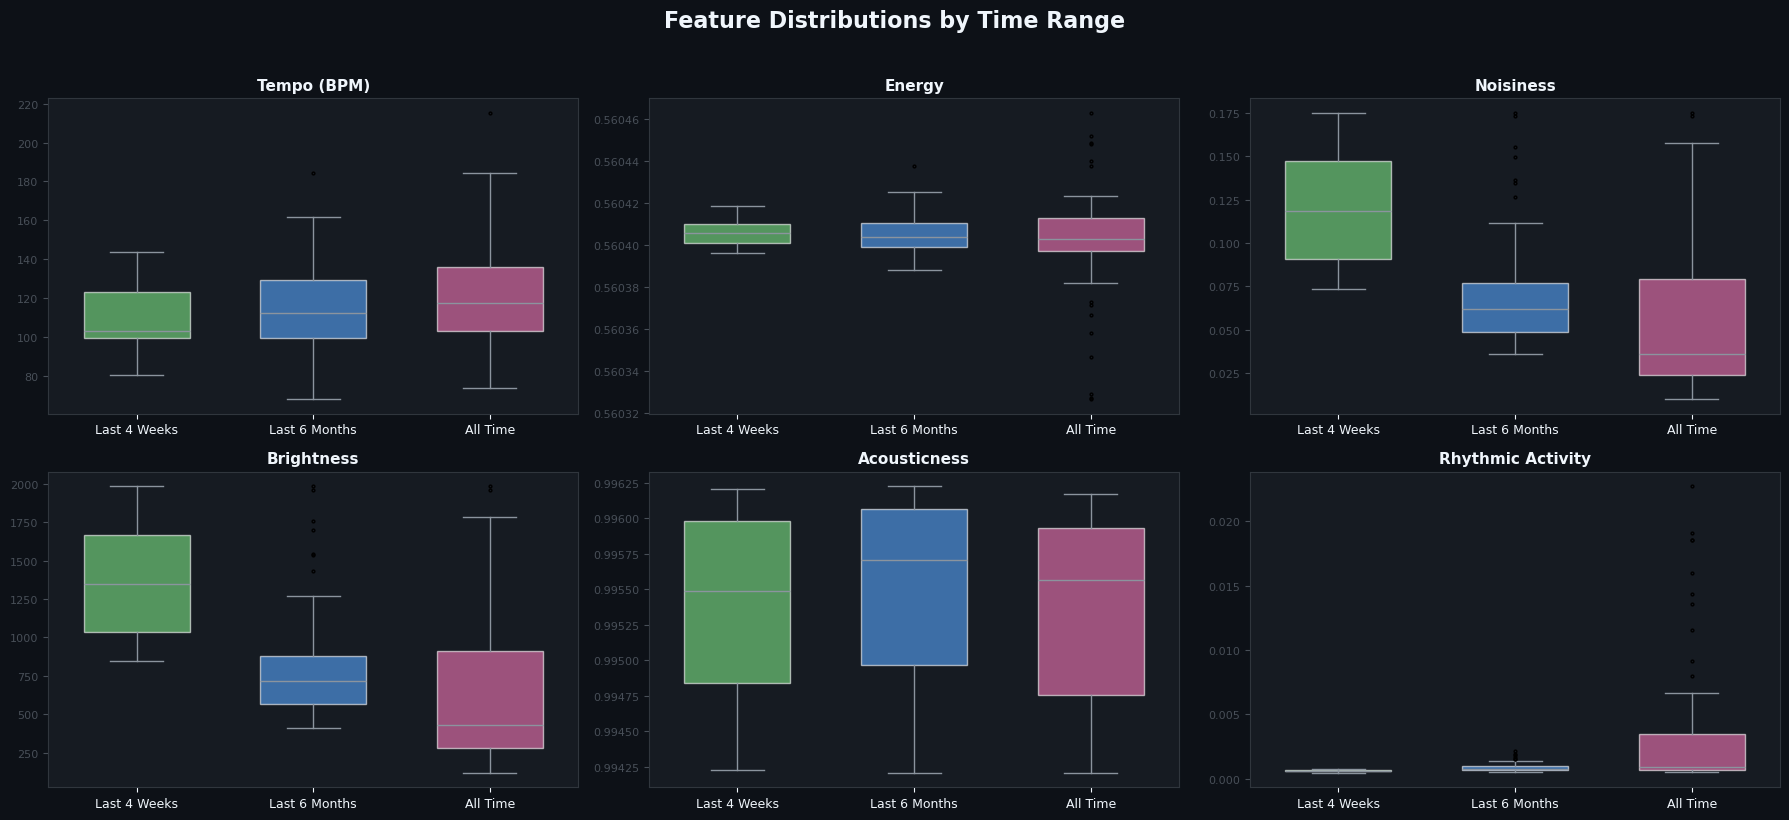

In [38]:
fig = plot_feature_distributions(fact)
plt.show()

**Reading the box plots:** The boxes show the interquartile range (25th–75th percentile).
If the entire box shifts between time ranges (not just outliers), the drift is a
genuine distributional shift, not driven by a few extreme tracks.

---
## Section 6: Agent-Ready Insight Queries

These queries demonstrate the star schema's value for AI agent consumption.
Each query returns a deterministic, structured answer.

In [39]:
# Query 1: What is the user's highest-energy track per time range?
print("🔍 Query 1: Highest-Energy Track Per Time Range\n")
if "rms_mean" in fact.columns:
    for tr in ["short_term", "medium_term", "long_term"]:
        subset = fact[fact["time_range"] == tr]
        if not subset.empty and "rms_mean" in subset.columns:
            top = subset.nlargest(1, "rms_mean").iloc[0]
            print(f"  {tr:15s} → {top.get('track_name', 'N/A'):35s} (energy: {top['rms_mean']:.4f})")

🔍 Query 1: Highest-Energy Track Per Time Range

  short_term      → Starlight                           (energy: 0.5604)
  medium_term     → Hey Gringo                          (energy: 0.5604)
  long_term       → What I've Done                      (energy: 0.5605)


In [40]:
# Query 2: How many unique tracks appear in multiple time ranges?
print("🔍 Query 2: Track Persistence Across Time Ranges\n")
track_ranges = fact.groupby("spotify_track_id")["time_range"].nunique()
multi = track_ranges[track_ranges > 1]
print(f"  Tracks appearing in 1 time range:  {(track_ranges == 1).sum()}")
print(f"  Tracks appearing in 2+ time ranges: {len(multi)}")
if len(multi) > 0:
    print(f"\n  Persistent tracks (appear across time ranges):")
    for tid in multi.index[:5]:
        name = fact[fact["spotify_track_id"] == tid]["track_name"].iloc[0]
        ranges = fact[fact["spotify_track_id"] == tid]["time_range"].unique()
        print(f"    {name:35s} → {', '.join(ranges)}")

🔍 Query 2: Track Persistence Across Time Ranges

  Tracks appearing in 1 time range:  129
  Tracks appearing in 2+ time ranges: 30

  Persistent tracks (appear across time ranges):
    This Is Letting Go                  → short_term, long_term
    Holiday / Boulevard of Broken Dreams → medium_term, long_term, short_term
    Madness                             → medium_term, long_term
    What A Catch, Donnie                → medium_term, short_term
    Rich Girl                           → medium_term, long_term


In [41]:
# Query 3: Average acoustic profile per time range (agent-friendly)
print("🔍 Query 3: Acoustic Summary Per Time Range\n")
summary_features = ["tempo_bpm", "rms_mean", "harmonic_ratio", "spectral_centroid_mean"]
available_sf = [c for c in summary_features if c in fact.columns]
if available_sf:
    summary = fact.groupby("time_range")[available_sf].mean()
    for col in available_sf:
        desc = COLUMN_DESCRIPTIONS.get(col, col)
        print(f"  {col}: {desc[:60]}")
    print()
    print(summary.round(4).to_string())

🔍 Query 3: Acoustic Summary Per Time Range

  tempo_bpm: Estimated tempo in beats per minute. Typical range: 60–200 B
  rms_mean: Root Mean Square energy (perceived loudness). Range: 0–1. Re
  harmonic_ratio: Harmonic-to-total energy ratio (0–1). Near 1 = acoustic/harm
  spectral_centroid_mean: Center of mass of the spectrum (Hz). High = bright sound (cy

              tempo_bpm  rms_mean  harmonic_ratio  spectral_centroid_mean
time_range                                                               
long_term    121.139198    0.5604          0.9953              638.505188
medium_term  115.795799    0.5604          0.9955              803.512573
short_term   108.174301    0.5604          0.9954             1366.197632


In [ ]:
# Query 4: Feature with the largest temporal shift
print("\n🔍 Query 4: Biggest Taste Shift Driver\n")
deltas = drift_results["feature_deltas"]
if not deltas.empty:
    top_delta = deltas.iloc[0]
    arrow = "↑" if top_delta["direction"] == "increasing" else "↓"
    print(f"  {arrow} {top_delta['label']}: {top_delta['relative_delta_pct']:.1f}% change")
    print(f"    Short-term value: {top_delta['short_term']:.4f}")
    print(f"    Long-term value:  {top_delta['long_term']:.4f}")
    print(f"    Direction:        {top_delta['direction']}")


🔍 Query 4: Biggest Taste Shift Driver

  ↑ Brightness: 114.0% change
    Short-term value: 1366.1976
    Long-term value:  638.5051
    Direction:        increasing


: 

---
## Section 7: Pipeline Summary & Architecture

### Data Lineage

```
Spotify API (3 time ranges, 50 tracks each)
    │
    ▼
STAGING (data/staging/)
    │  tracks_raw_*.parquet + features_raw_*.parquet
    │  + lineage: _landed_at, _source, _snapshot_label
    │
    ▼
CLEANSED (data/cleansed/)
    │  Dedup: (track_id, time_range) for tracks; track_id for features
    │  Type enforcement: Float32 features, String IDs, Bool flags
    │  Null handling: numerics → 0.0, strings → "unknown"
    │
    ▼
MODELED (data/modeled/)
    │  fact_listening_features: grain = track × time_range
    │  dim_tracks, dim_artists, dim_time_range
    │  column_descriptions (28 agent-readable descriptions)
    │
    ▼
ANALYSIS
    Taste Drift Score, Temporal Centroids, Feature Deltas
    5 publication-quality visualizations
```

### Tech Stack

| Component | Technology | Why |
|---|---|---|
| Audio DSP | librosa + numpy | Industry-standard MIR, 77D feature vectors |
| Batch Processing | PySpark | Distributed transforms, cluster-ready |
| Serialization | Apache Parquet (PyArrow) | Columnar, typed, compressed |
| Vector Search | FAISS | 10M vectors/sec cosine similarity |
| Dimensionality Reduction | UMAP | Preserves local + global structure |
| Visualization | matplotlib | Full control, dark theme consistency |

### PySpark Jobs (Cluster-Ready)

The warehouse transforms exist in both pandas (`src/warehouse/`) and PySpark (`spark/`) versions:

```bash
# Run distributed transforms
spark-submit spark/feature_transform.py    # Staging → Cleansed
spark-submit spark/temporal_aggregate.py   # Centroids + drift metrics
```

---
*Temporal Audio Pipeline — Jordan Vercillo, 2026*
*Built for the love of music data.*